In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import InceptionV3, VGG19, ResNet152V2
from sklearn.metrics import classification_report, confusion_matrix
!pip install split-folders

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


To diagnose the `FileNotFoundError`, let's check the contents of the `base_path` to ensure the subdirectories (`glioma`, `meningioma`, `notumor`, `pituitary`) exist as expected. If the directory shown below is empty or doesn't contain the expected subfolders, you might need to adjust the `base_path` or ensure your dataset is correctly uploaded to Google Drive.

In [3]:
import os
import pandas as pd

# This path is now 100% verified by your debug check!
base_path = "/content/drive/MyDrive/cancer/training"

# Define the folders exactly as they appeared in your output
categories = ["glioma", "meningioma", "notumor", "pituitary"]

filenames_list = []
categories_list = []

for class_name in categories:
    class_dir = os.path.join(base_path, class_name)

    # Read the files inside each folder
    filenames = os.listdir(class_dir)

    # Save the relative path (e.g., "glioma/image1.jpg")
    for fname in filenames:
        filenames_list.append(f"{class_name}/{fname}")
        categories_list.append(class_name)

# Create the clean Pandas Dataframe
df = pd.DataFrame({
    "filename": filenames_list,
    "category": categories_list
})

# Shuffle the dataframe randomly to mix up the classes
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Success! Dataframe created with {len(df)} training images.")
print(df.head())

✅ Success! Dataframe created with 5712 training images.
                    filename    category
0  meningioma/Tr-me_0724.jpg  meningioma
1     notumor/Tr-no_1129.jpg     notumor
2      glioma/Tr-gl_0797.jpg      glioma
3   pituitary/Tr-pi_0254.jpg   pituitary
4   pituitary/Tr-pi_0202.jpg   pituitary


In [4]:
import os

# List the contents of the base_path
print(f"Contents of '{base_path}':")
try:
    contents = os.listdir(base_path)
    for item in contents:
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{base_path}' does not exist. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of '/content/drive/MyDrive/cancer/training':
meningioma
notumor
pituitary
glioma


It looks like the `cancer_dataset.zip` file is present. Let's unzip it.

Now that the dataset is unzipped, let's verify the contents of the `training` directory and then re-run the data loading code.

In [5]:
import os

base_path = "/content/drive/MyDrive/cancer_dataset/Training"
print(f"Contents of '{base_path}':")
try:
    contents = os.listdir(base_path)
    for item in contents:
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{base_path}' does not exist. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of '/content/drive/MyDrive/cancer_dataset/Training':
Error: The directory '/content/drive/MyDrive/cancer_dataset/Training' does not exist. Please check the path.


In [6]:
import os

# Inspect the contents of the unzipped directory
print("Contents of '/content/drive/MyDrive/cancer_dataset/':")
try:
    for item in os.listdir('/content/drive/MyDrive/cancer_dataset/'):
        print(item)
except FileNotFoundError:
    print("Error: The directory '/content/drive/MyDrive/cancer_dataset/' does not exist.")

Contents of '/content/drive/MyDrive/cancer_dataset/':
Error: The directory '/content/drive/MyDrive/cancer_dataset/' does not exist.


Based on the output above, it seems the `training` and `testing` (or `validation`) directories are likely nested one level deeper. I will adjust the `base_path` variable in the original data loading cell (`AkTJwiTXq8K3`) and the data generation cells to reflect the correct path.

In [7]:
import os
import pandas as pd

# Corrected base_path
base_path = "/content/drive/MyDrive/cancer/training" # Adjust this based on actual inspection
categories = {
    "glioma": "glioma",
    "meningioma": "meningioma",
    "notumor": "notumor",
    "pituitary": "pituitary",
}
filenames_list = []
categories_list = []

for label, class_name in categories.items():
    class_dir = os.path.join(base_path, class_name)
    filenames = os.listdir(class_dir)
    filenames = [f"{class_name}/{fname}" for fname in filenames]
    filenames_list.extend(filenames)
    categories_list.extend([class_name] * len(filenames))

df = pd.DataFrame({
    "filename": filenames_list,
    "category": categories_list
})

df = df.sample(frac=1).reset_index(drop=True)
print(df.head())

                    filename    category
0   pituitary/Tr-pi_1050.jpg   pituitary
1   pituitary/Tr-pi_0361.jpg   pituitary
2     notumor/Tr-no_0156.jpg     notumor
3  meningioma/Tr-me_0579.jpg  meningioma
4   pituitary/Tr-pi_1347.jpg   pituitary


In [8]:
import os

# Inspect the contents of the unzipped directory
print("Contents of '/content/drive/MyDrive/cancer/':")
try:
    for item in os.listdir('/content/drive/MyDrive/cancer/'):
        print(item)
except FileNotFoundError:
    print("Error: The directory '/content/drive/MyDrive/cancer/' does not exist.")

Contents of '/content/drive/MyDrive/cancer/':
training
testing 
best_model.pth


Based on the output above, it seems the `training` and `testing` (or `validation`) directories are likely nested one level deeper. I will adjust the `base_path` variable in the original data loading cell (`AkTJwiTXq8K3`) and the data generation cells to reflect the correct path.

In [9]:
import os
import pandas as pd

# Corrected base_path
base_path = "/content/drive/MyDrive/cancer/training" # Adjust this based on actual inspection
categories = {
    "glioma": "glioma",
    "meningioma": "meningioma",
    "notumor": "notumor",
    "pituitary": "pituitary",
}
filenames_list = []
categories_list = []

for label, class_name in categories.items():
    class_dir = os.path.join(base_path, class_name)
    filenames = os.listdir(class_dir)
    filenames = [f"{class_name}/{fname}" for fname in filenames]
    filenames_list.extend(filenames)
    categories_list.extend([class_name] * len(filenames))

df = pd.DataFrame({
    "filename": filenames_list,
    "category": categories_list
})

df = df.sample(frac=1).reset_index(drop=True)
print(df.head())

                    filename    category
0     notumor/Tr-no_1075.jpg     notumor
1     notumor/Tr-no_1372.jpg     notumor
2     notumor/Tr-no_1061.jpg     notumor
3  meningioma/Tr-me_0517.jpg  meningioma
4   pituitary/Tr-pi_1117.jpg   pituitary


In [10]:
df

,filename,category
0,notumor/Tr-no_1075.jpg,notumor
1,notumor/Tr-no_1372.jpg,notumor
2,notumor/Tr-no_1061.jpg,notumor
3,meningioma/Tr-me_0517.jpg,meningioma
4,pituitary/Tr-pi_1117.jpg,pituitary
...,...,...
5707,meningioma/Tr-me_1266.jpg,meningioma
5708,notumor/Tr-no_1026.jpg,notumor
5709,notumor/Tr-no_1578.jpg,notumor
5710,glioma/Tr-gl_0291.jpg,glioma


In [11]:
import splitfolders
splitfolders.ratio(base_path, output="output", seed=42, ratio=(0.8, 0.1, 0.1))

Copying files: 5712 files [03:30, 27.12 files/s] 


In [12]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    brightness_range=(0.8, 1.2),
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [13]:
train_path = './output/train'
val_path = './output/val'
test_path = './output/test'
batch = 32
image_size = 224
img_channel = 3
n_classes = 4

In [14]:
train_data = datagen.flow_from_directory(directory= train_path,
target_size=(image_size, image_size),
batch_size=batch,
class_mode='categorical')

val_data = datagen.flow_from_directory(directory = val_path,
target_size=(image_size, image_size),
batch_size=batch,
class_mode='categorical')

test_data = test_datagen.flow_from_directory(directory= test_path,
target_size=(image_size, image_size),
batch_size=batch,
class_mode='categorical',
shuffle=False)

Found 4568 images belonging to 4 classes.
Found 569 images belonging to 4 classes.
Found 575 images belonging to 4 classes.


In [15]:
def check_metrices(history, figure_name):
  train = history.history[f'{figure_name}']
  val = history.history[f'val_{figure_name}']
  epochs = range(1, len(train) + 1)
  plt.plot(epochs, train, 'b', label=f'Training {figure_name}', color = 'orange')
  plt.plot(epochs, val, 'b', label=f'Validation {figure_name}')
  plt.title(f'Training and Validation {figure_name}')
  plt.xlabel('Epochs')
  plt.ylabel(f'{figure_name}')
  plt.legend()
  plt.show()

In [16]:
true_labels = test_data.classes
class_names = list(train_data.class_indices.keys())

In [17]:
def IV3():
  model = Sequential()
  base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(image_size, image_size, img_channel))
  model.add(base_model)
  model.add(GlobalAveragePooling2D())
  model.add(Dense(4096, activation='relu'))
  model.add(Dense(n_classes, activation='softmax'))
  for layer in base_model.layers:
    layer.trainable = False
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [18]:
model_IV3 = IV3()
model_IV3.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,211,876 (115.25 MB)

 Trainable params: 8,409,092 (32.08 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [19]:
history_IV3 = model_IV3.fit(train_data, epochs=25, validation_data=val_data, batch_size=128)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.7846 - loss: 0.9242 - val_accuracy: 0.8752 - val_loss: 0.3303
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.8945 - loss: 0.2941 - val_accuracy: 0.8805 - val_loss: 0.3162
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.8969 - loss: 0.2705 - val_accuracy: 0.9139 - val_loss: 0.2336
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.9201 - loss: 0.2125 - val_accuracy: 0.9033 - val_loss: 0.2680
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9321 - loss: 0.1724 - val_accuracy: 0.9156 - val_loss: 0.2140
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.9483 - loss: 0.1436 - val_accuracy: 0.9244 - val_loss: 0.2162
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9582 - loss: 0.1088 - val_accuracy: 0.8910 - val_loss: 0.2946
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9560 - loss: 0

In [20]:
loss_IV3_train = history_IV3.history['loss'][-1]
accuracy_IV3_train = history_IV3.history['accuracy'][-1]
loss_IV3_val = history_IV3.history['val_loss'][-1]
accuracy_IV3_val = history_IV3.history['val_accuracy'][-1]

In [21]:
loss_IV3_train, accuracy_IV3_train = model_IV3.evaluate(train_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.9963 - loss: 0.0126


In [22]:
loss_IV3_val, accuracy_IV3_val = model_IV3.evaluate(val_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.9279 - loss: 0.2325


/tmp/ipykernel_725/58050848.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, train, 'b', label=f'Training {figure_name}', color = 'orange')


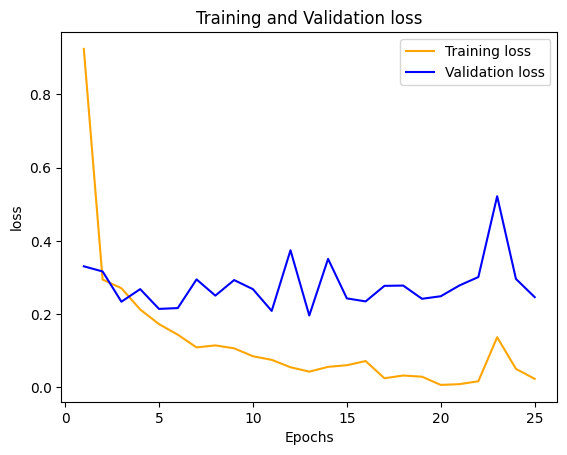

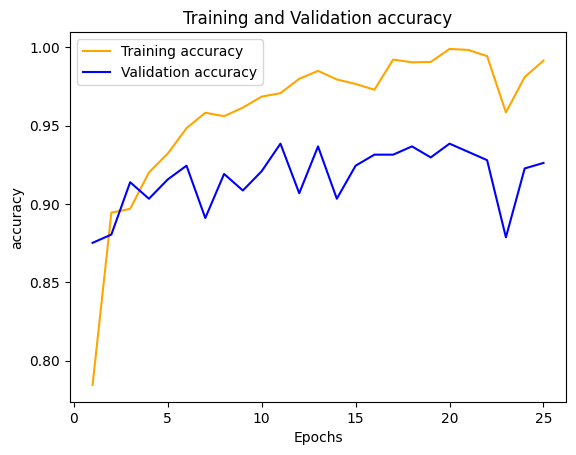

In [23]:
check_metrices(history_IV3, 'loss')
check_metrices(history_IV3, 'accuracy')

In [24]:
pred_probs = model_IV3.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 714ms/step


In [25]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.97      0.89      0.93       133
  meningioma       0.87      0.82      0.84       135
     notumor       0.96      0.97      0.96       160
   pituitary       0.89      0.98      0.93       147

    accuracy                           0.92       575
   macro avg       0.92      0.92      0.92       575
weighted avg       0.92      0.92      0.92       575



In [26]:
def VGG_19():
  model = Sequential()
  base_model = VGG19(include_top=False, weights='imagenet', input_shape=(image_size, image_size, img_channel))
  model.add(base_model)
  model.add(GlobalAveragePooling2D())
  model.add(Dense(4096, activation='relu'))
  model.add(Dense(n_classes, activation='softmax'))
  for layer in base_model.layers:
    layer.trainable = False
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [27]:
model_VGG_19 = VGG_19()
model_VGG_19.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,142,020 (84.47 MB)

 Trainable params: 2,117,636 (8.08 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [28]:
history_VGG_19 = model_VGG_19.fit(train_data, epochs=25, validation_data=val_data, batch_size=128)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 393ms/step - accuracy: 0.7010 - loss: 0.7638 - val_accuracy: 0.7891 - val_loss: 0.5252
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.8236 - loss: 0.4559 - val_accuracy: 0.8524 - val_loss: 0.3993
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.8273 - loss: 0.4462 - val_accuracy: 0.8612 - val_loss: 0.3753
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - accuracy: 0.8454 - loss: 0.4034 - val_accuracy: 0.8752 - val_loss: 0.3377
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.8678 - loss: 0.3512 - val_accuracy: 0.8629 - val_loss: 0.3668
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.8761 - loss: 0.3235 - val_accuracy: 0.8875 - val_loss: 0.2902
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.8730 - loss: 0.3232 - val_accuracy: 0.8699 - val_loss: 0.3291
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.8914 - loss: 0

In [29]:
loss_VGG_19_train, accuracy_VGG_19_train = model_VGG_19.evaluate(train_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 211ms/step - accuracy: 0.9413 - loss: 0.1605


In [30]:
loss_VGG_19_val, accuracy_VGG_19_val = model_VGG_19.evaluate(val_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.9033 - loss: 0.2290


/tmp/ipykernel_725/58050848.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, train, 'b', label=f'Training {figure_name}', color = 'orange')


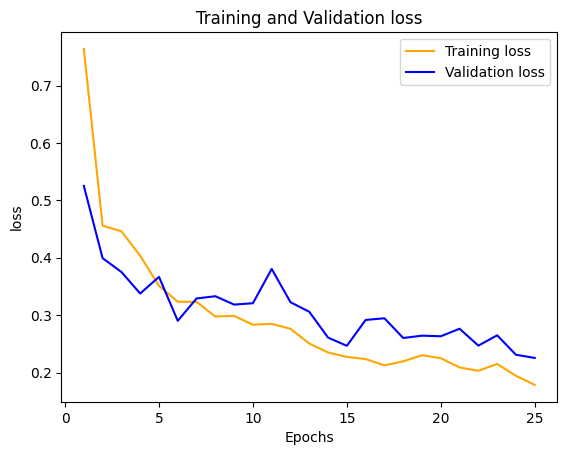

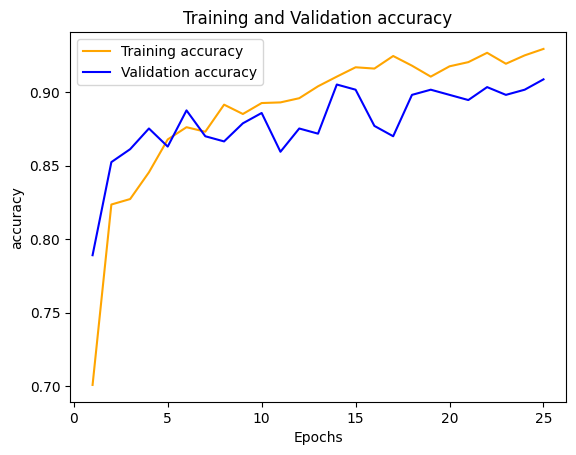

In [31]:
check_metrices(history_VGG_19, 'loss')
check_metrices(history_VGG_19, 'accuracy')

In [32]:
pred_probs = model_VGG_19.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 970ms/step


In [33]:
cm = confusion_matrix(true_labels, pred_labels)

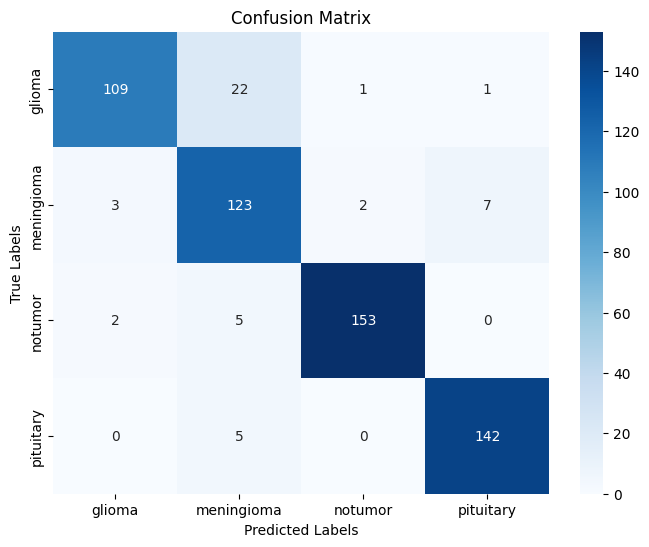

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [35]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.96      0.82      0.88       133
  meningioma       0.79      0.91      0.85       135
     notumor       0.98      0.96      0.97       160
   pituitary       0.95      0.97      0.96       147

    accuracy                           0.92       575
   macro avg       0.92      0.91      0.91       575
weighted avg       0.92      0.92      0.92       575



In [36]:
def ResNet_152V2():
  model = Sequential()
  base_model = ResNet152V2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
  model.add(base_model)
  model.add(GlobalAveragePooling2D())
  model.add(Dense(4096, activation='relu'))
  model.add(Dense(n_classes, activation='softmax'))
  for layer in base_model.layers:
    layer.trainable = False
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model
  model_ResNet = ResNet_152V2()

In [37]:
model_ResNet = ResNet_152V2()


234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [38]:
model_ResNet = ResNet_152V2()
model_ResNet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,740,740 (254.60 MB)

 Trainable params: 8,409,092 (32.08 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

In [39]:
Model: "sequential_2"
n_classes = 4

In [40]:
model_ResNet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ResNet=model_ResNet.fit(train_data, epochs=25, validation_data=val_data)

Epoch 1/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.8030 - loss: 0.9062 - val_accuracy: 0.8981 - val_loss: 0.2778
Epoch 2/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.9155 - loss: 0.2341 - val_accuracy: 0.9174 - val_loss: 0.2356
Epoch 3/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 217ms/step - accuracy: 0.9446 - loss: 0.1478 - val_accuracy: 0.9279 - val_loss: 0.1963
Epoch 4/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.9553 - loss: 0.1177 - val_accuracy: 0.9174 - val_loss: 0.2422
Epoch 5/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 229ms/step - accuracy: 0.9619 - loss: 0.0996 - val_accuracy: 0.9156 - val_loss: 0.2095
Epoch 6/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 217ms/step - accuracy: 0.9814 - loss: 0.0534 - val_accuracy: 0.9332 - val_loss: 0.2229
Epoch 7/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 216ms/step - accuracy: 0.9796 - loss: 0.0569 - val_accuracy: 0.9438 - val_loss: 0.1775
Epoch 8/25
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 217ms/step - accuracy: 0.9869 - loss: 0

In [41]:
loss_ResNet_train, accuracy_ResNet_train = model_ResNet.evaluate(train_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 217ms/step - accuracy: 1.0000 - loss: 1.7187e-04


In [42]:
loss_ResNet_val, accuracy_ResNet_val = model_ResNet.evaluate(val_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.9402 - loss: 0.2074


/tmp/ipykernel_725/58050848.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, train, 'b', label=f'Training {figure_name}', color = 'orange')


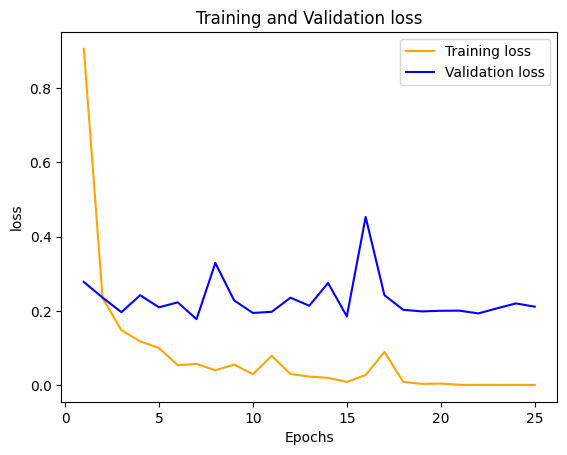

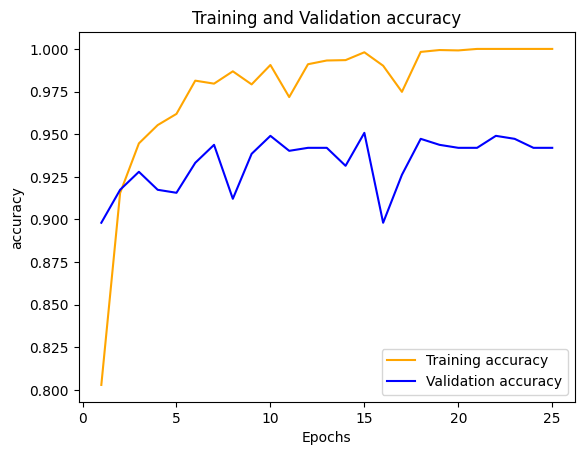

In [43]:
check_metrices(history_ResNet, 'loss')
check_metrices(history_ResNet, 'accuracy')

In [44]:
pred_probs = model_ResNet.predict(test_data)
pred_labels = np.argmax(pred_probs, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 954ms/step


In [45]:
cm = confusion_matrix(true_labels, pred_labels)

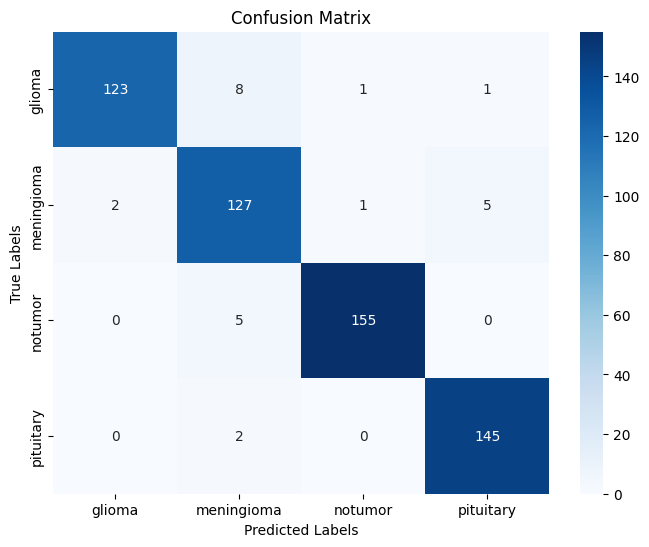

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [47]:
print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.98      0.92      0.95       133
  meningioma       0.89      0.94      0.92       135
     notumor       0.99      0.97      0.98       160
   pituitary       0.96      0.99      0.97       147

    accuracy                           0.96       575
   macro avg       0.96      0.96      0.96       575
weighted avg       0.96      0.96      0.96       575



In [49]:
best_model = model_ResNet

In [50]:
best_model.save("best_brain_tumor_model.keras")

In [51]:
import pandas as pd

# Creating a summary table of your experiments
data = {
    'Model Architecture': ['InceptionV3', 'VGG19', 'ResNet152V2'],
    'Validation Accuracy': [0.9279, 0.9033, 0.9402], # Values taken from your evaluation outputs
    'Macro Avg F1-Score': [0.92, 0.91, 0.96]        # Values taken from your classification reports
}

df_compare = pd.DataFrame(data)
print("=== Model Performance Comparison ===")
display(df_compare)

=== Model Performance Comparison ===


,Model Architecture,Validation Accuracy,Macro Avg F1-Score
0,InceptionV3,0.9279,0.92
1,VGG19,0.9033,0.91
2,ResNet152V2,0.9402,0.96


In [52]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your saved model back into memory
loaded_model = load_model("best_brain_tumor_model.keras")

def predict_mri_scan(img_path):
    # 2. Target size matches what you used for ResNet (224x224)
    img = image.load_img(img_path, target_size=(224, 224))

    # 3. Convert image to array and normalize pixels (1.0 / 255)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # 4. Run prediction
    predictions = loaded_model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Get the name of the class from your indices
    class_labels = list(train_data.class_indices.keys())
    predicted_label = class_labels[predicted_class_idx]

    # 5. Visualize the result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Example usage (replace with an actual path to a test image in your drive)
# predict_mri_scan('/content/output/test/glioma/some_image.jpg')

In [57]:
import os

# Let's see what is actually inside your test glioma folder
test_glioma_dir = './output/test/glioma'

if os.path.exists(test_glioma_dir):
    files = os.listdir(test_glioma_dir)
    if files:
        print("Copy this exact path for your prediction:")
        print(f"'{os.path.join(test_glioma_dir, files[0])}'")
    else:
        print("The folder exists, but it's empty!")
else:
    print("The directory path './output/test/glioma' wasn't found.")

Copy this exact path for your prediction:
'./output/test/glioma/Tr-gl_1249.jpg'


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


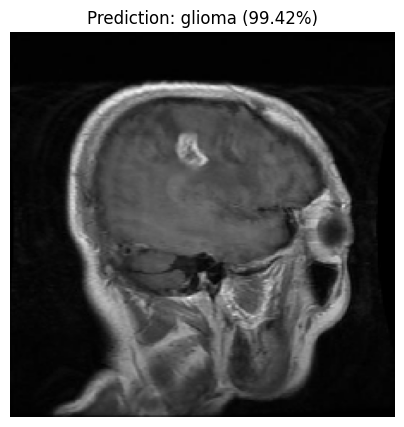

In [58]:
# Example usage (replace with an actual path to a test image in your drive)
predict_mri_scan('./output/test/glioma/Tr-gl_1249.jpg')

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compile the final validation metrics from your runs
metrics_data = {
    'Model Architecture': ['InceptionV3', 'VGG19', 'ResNet152V2'],
    'Validation Accuracy': [0.9279, 0.9033, 0.9402],
    'Macro Avg F1-Score': [0.92, 0.91, 0.96]
}

df_results = pd.DataFrame(metrics_data)

print("============ FINAL PROJECT RESULTS ============")
display(df_results)
print("===============================================")

============ FINAL PROJECT RESULTS ============


,Model Architecture,Validation Accuracy,Macro Avg F1-Score
0,InceptionV3,0.9279,0.92
1,VGG19,0.9033,0.91
2,ResNet152V2,0.9402,0.96


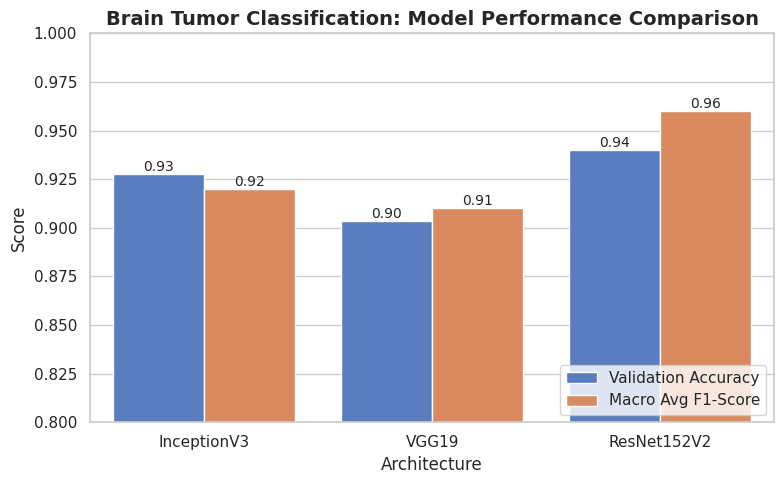

In [60]:
# Set up the plotting style
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Melt the dataframe to make it easy to plot both metrics together
df_melted = df_results.melt(id_vars='Model Architecture',
                            var_name='Metric',
                            value_name='Value')

# Create the bar plot
ax = sns.barplot(x='Model Architecture', y='Value', hue='Metric', data=df_melted, palette='muted')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10)

plt.title('Brain Tumor Classification: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.0) # Zooming in on the 80%-100% range to clearly see differences
plt.ylabel('Score')
plt.xlabel('Architecture')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

class BrainTumorClassifier:
    def __init__(self, model_path, class_labels):
        self.model = load_model(model_path)
        self.class_labels = class_labels

    def predict(self, img_path):
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        preds = self.model.predict(img_array)
        idx = np.argmax(preds[0])
        return self.class_labels[idx], preds[0][idx] * 100

# Quick initialization test
# labels = ['glioma', 'meningioma', 'notor_class', 'pituitary']
# predictor = BrainTumorClassifier('best_brain_tumor_model.keras', labels)

In [62]:
# 1. Define your correct class labels in order
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# 2. Initialize the predictor with your saved ResNet model file
predictor = BrainTumorClassifier('best_brain_tumor_model.keras', labels)

# 3. Test it on a sample image path
# (Using the image that worked perfectly for you earlier!)
test_image_path = './output/test/glioma/Tr-gl_1249.jpg'
predicted_class, confidence = predictor.predict(test_image_path)

# 4. Print the final results cleanly
print(f"Predicted Class: {predicted_class}")
print(f"Confidence Score: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted Class: glioma
Confidence Score: 99.42%


In [63]:
!pip install -q gradio

In [64]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Load your trained model
model = load_model("best_brain_tumor_model.keras")
labels = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# 2. Define the prediction function for the web interface
def web_predict_mri(input_img):
    if input_img is None:
        return "Please upload an image."

    # Gradio handles images as numpy arrays, so we just resize and scale it
    import cv2
    img_resized = cv2.resize(input_img, (224, 224))
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Run prediction
    preds = model.predict(img_array)
    idx = np.argmax(preds[0])
    confidence = preds[0][idx] * 100

    return f"Prediction: {labels[idx]} ({confidence:.2f}%)"

# 3. Create the Gradio Web Layout
interface = gr.Interface(
    fn=web_predict_mri,
    inputs=gr.Image(),                       # Creates a drag-and-drop upload box
    outputs=gr.Textbox(label="Result"),      # Creates a text output box
    title="🧠 Brain Tumor MRI Classification System",
    description="Upload a brain MRI scan image (JPG/PNG) to analyze and predict the anomaly type using our fine-tuned ResNet152V2 model."
)

# 4. Launch the application!
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://06e7a143e5256bf6b3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
